# Gravity calibration — phone orientation experiment
Four recordings simulate cycling movements with different phone positions: F = phone face and C = camera end. This notebook shows how the original phone-axis signals are projected onto a gravity reference. The same calculation is used in Assignment1.ipynb.

Run from top to bottom. The movement was repeated separately, so timing and amplitudes need not match perfectly between recordings.


## 1. Imports and loading


In [1]:
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [2]:
base_folder = Path("data_gravitycalibration")

recordings = ["Fdown-Cdown", "Fdown-Cup", "FupCdown", "Fup-Cup"]

sensor_files = {"acc": "Accelerometer.csv", "gyro": "Gyroscope.csv", "gravity": "Gravity.csv"}
titles = ["Accelerometer", "Gyroscope", "Gravity"]
units = ["m/s²", "rad/s", "m/s²"]

# Store the loaded recordings for later analysis
calibration_data = {}

for name in recordings:
    sensor_data = {}

    for sensor, filename in sensor_files.items():
        folder = base_folder / name

        if folder.is_dir():
            data = pd.read_csv(folder / filename)
        else:
            with ZipFile(base_folder / (name + ".zip")) as archive:
                file_path = next(path for path in archive.namelist() if Path(path).name == filename)

                with archive.open(file_path) as file:
                    data = pd.read_csv(file)

        sensor_data[sensor] = data

    calibration_data[name] = sensor_data


## 2. Raw sensor signals
The x/y/z coordinates are attached to the phone. Rotating the phone changes the components and their signs, even for similar leg movement. Inspect the gravity signals as well as acceleration and angular velocity.


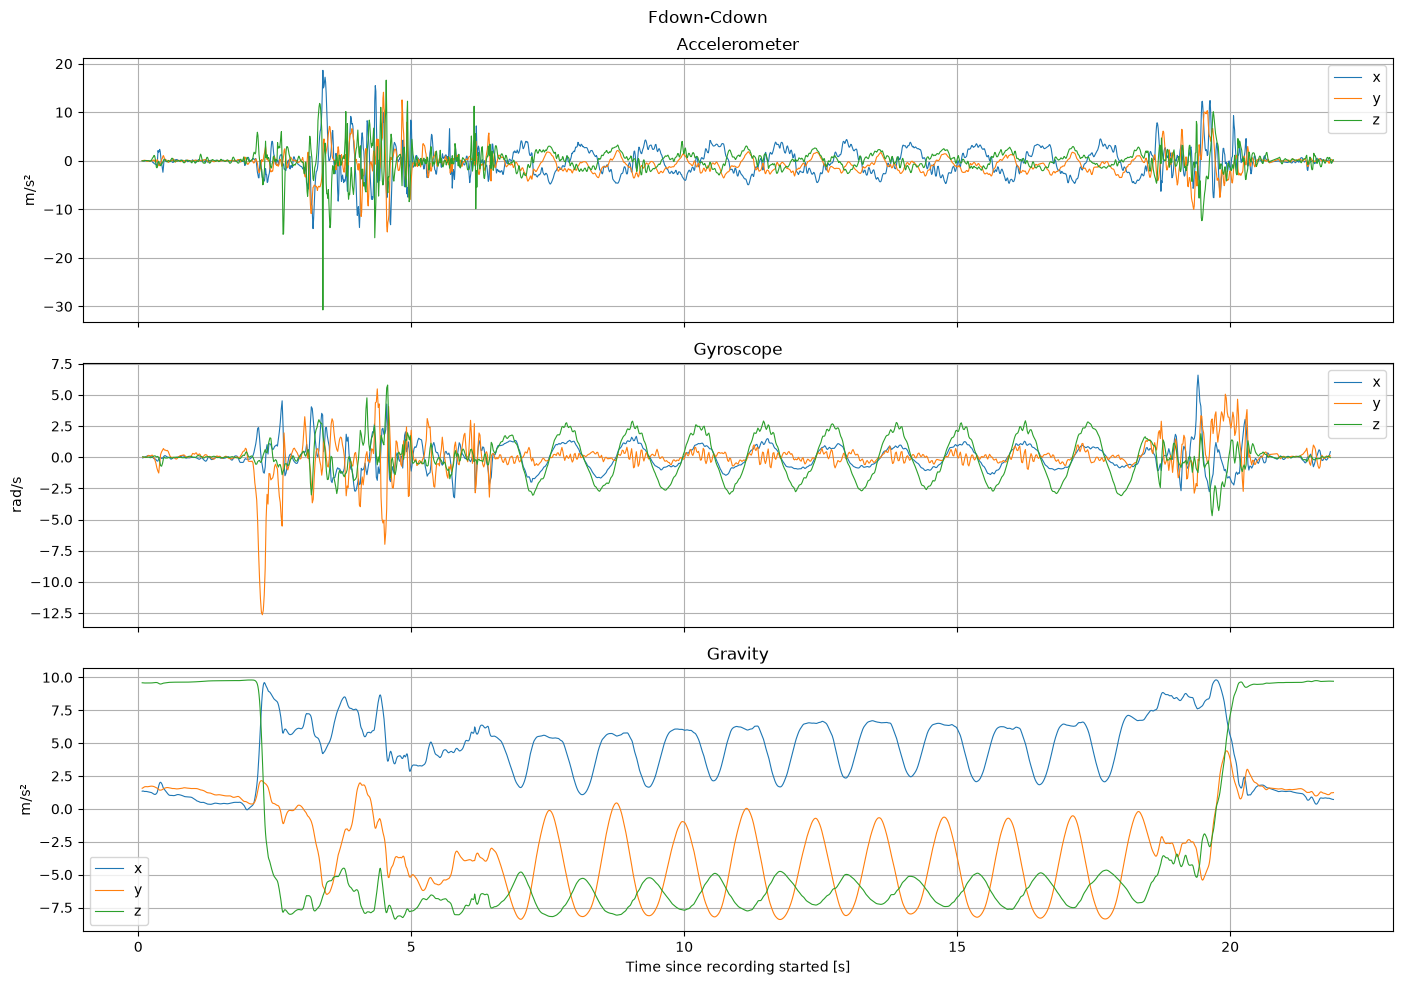

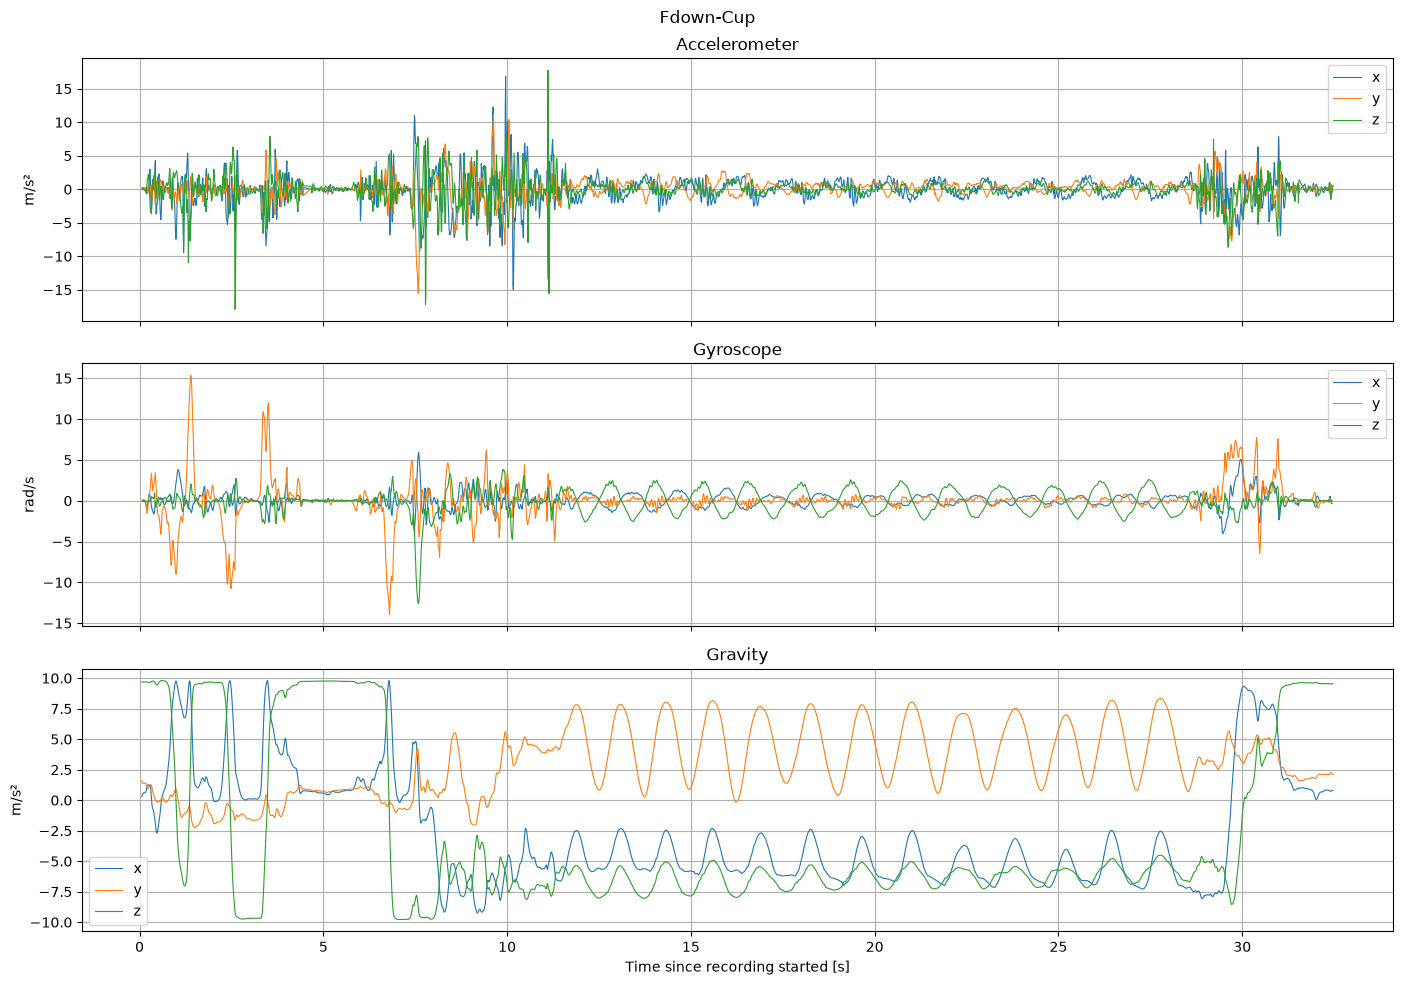

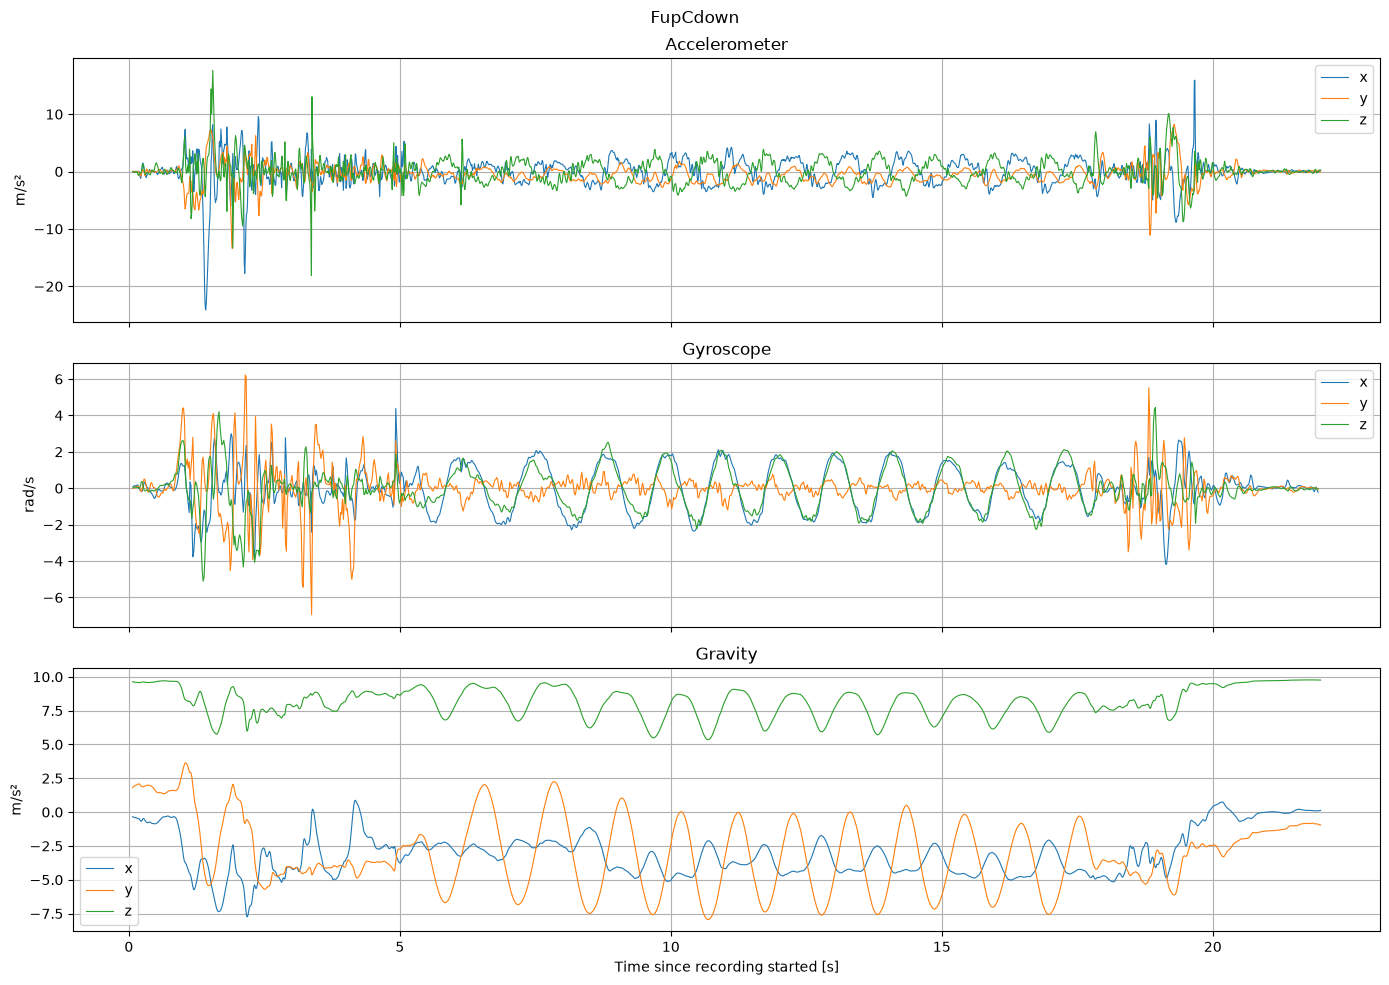

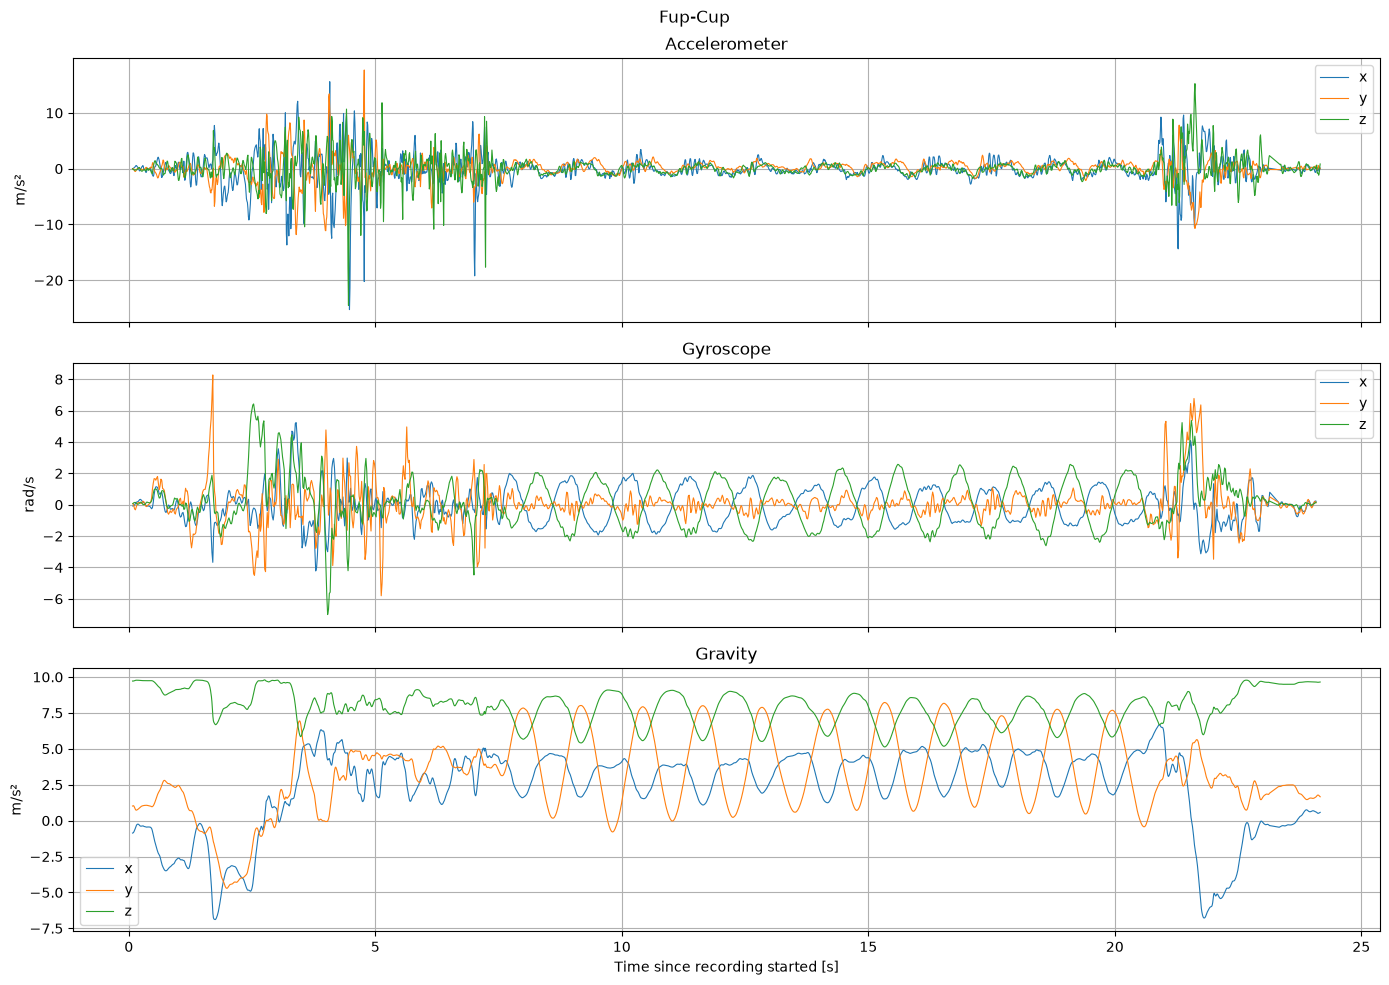

In [3]:
for name, sensor_data in calibration_data.items():
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    for i, sensor in enumerate(sensor_files):
        data = sensor_data[sensor]

        axes[i].plot(data["seconds_elapsed"], data[["x", "y", "z"]], linewidth=0.8)
        axes[i].set_title(titles[i])
        axes[i].set_ylabel(units[i])
        axes[i].legend(["x", "y", "z"])
        axes[i].grid(True)

    axes[2].set_xlabel("Time since recording started [s]")
    fig.suptitle(name)

    plt.tight_layout()
    plt.show()


## 3. Alignment and gravity projection
Align each axis to accelerometer timestamps over the shared sensor coverage using linear interpolation. Normalize the gravity vector at every sample: **ĝ = g / ‖g‖**.

For acceleration and gyroscope separately, calculate **vertical = v · ĝ**, then **horizontal magnitude = ‖v − vertical × ĝ‖**. The vertical component keeps its sign according to the gravity sensor convention. Horizontal magnitude combines both perpendicular directions and is always nonnegative.

Gyroscope components refer to rotation around these axes. This does not produce a forward/sideways reference or remove differences in how the phone moves within a pocket. The acceleration input is assumed to be gravity-removed already; this operation is a projection, not gravity subtraction.


In [4]:
corrected_data = {}

for name, sensor_data in calibration_data.items():
    # Use only the time range covered by all three sensors
    start = max(data["seconds_elapsed"].min() for data in sensor_data.values())
    end = min(data["seconds_elapsed"].max() for data in sensor_data.values())

    acc_times = sensor_data["acc"]["seconds_elapsed"]
    acc_times = acc_times[(acc_times >= start) & (acc_times <= end)]

    df_corrected = pd.DataFrame(index=acc_times.to_numpy())
    df_corrected.index.name = "Time [s]"

    # Align all axes to the accelerometer timestamps
    for sensor, data in sensor_data.items():
        for axis in ["x", "y", "z"]:
            linear_interp = interp1d(data["seconds_elapsed"], data[axis], kind="linear")
            df_corrected[sensor + "_" + axis] = linear_interp(df_corrected.index)

    # Normalize gravity to obtain the vertical reference direction
    gravity = df_corrected[["gravity_x", "gravity_y", "gravity_z"]].to_numpy()
    gravity_magnitude = np.sqrt(np.sum(gravity**2, axis=1))

    if np.any(~np.isfinite(gravity_magnitude)) or np.any(gravity_magnitude < 1e-6):
        raise ValueError(name + ": gravity direction is undefined for a zero gravity vector")

    gravity_direction = gravity / gravity_magnitude[:, None]

    # Project acceleration and angular velocity onto that direction
    for sensor in ["acc", "gyro"]:
        values = df_corrected[[sensor + "_x", sensor + "_y", sensor + "_z"]].to_numpy()

        vertical = np.sum(values * gravity_direction, axis=1)
        horizontal_vector = values - vertical[:, None] * gravity_direction
        horizontal = np.sqrt(np.sum(horizontal_vector**2, axis=1))

        df_corrected[sensor + "_vertical"] = vertical
        df_corrected[sensor + "_horizontal"] = horizontal

    corrected_data[name] = df_corrected


## 4. Select comparable movement intervals
These initial intervals exclude the visible handling at the beginning and end. Adjust them using the raw plots. Comparisons below reset each interval's time to zero for display; they do not align individual movement cycles.


In [5]:
comparison_cuts = {"Fdown-Cdown": (7, 18), "Fdown-Cup": (12, 28), "FupCdown": (7, 17), "Fup-Cup": (8, 20)}
comparison_data = {}
for name, data in corrected_data.items():
    start, end = comparison_cuts[name]
    if start >= end or start < data.index[0] or end > data.index[-1]:
        raise ValueError("Check the comparison interval for " + name)
    comparison_data[name] = data.loc[start:end].copy()


## 5. Before and after projection
Each row is one phone position. The first two columns show the original acceleration and gyroscope axes; the final two show their gravity-referenced components. Shared scales within each column make differences between recordings visible.


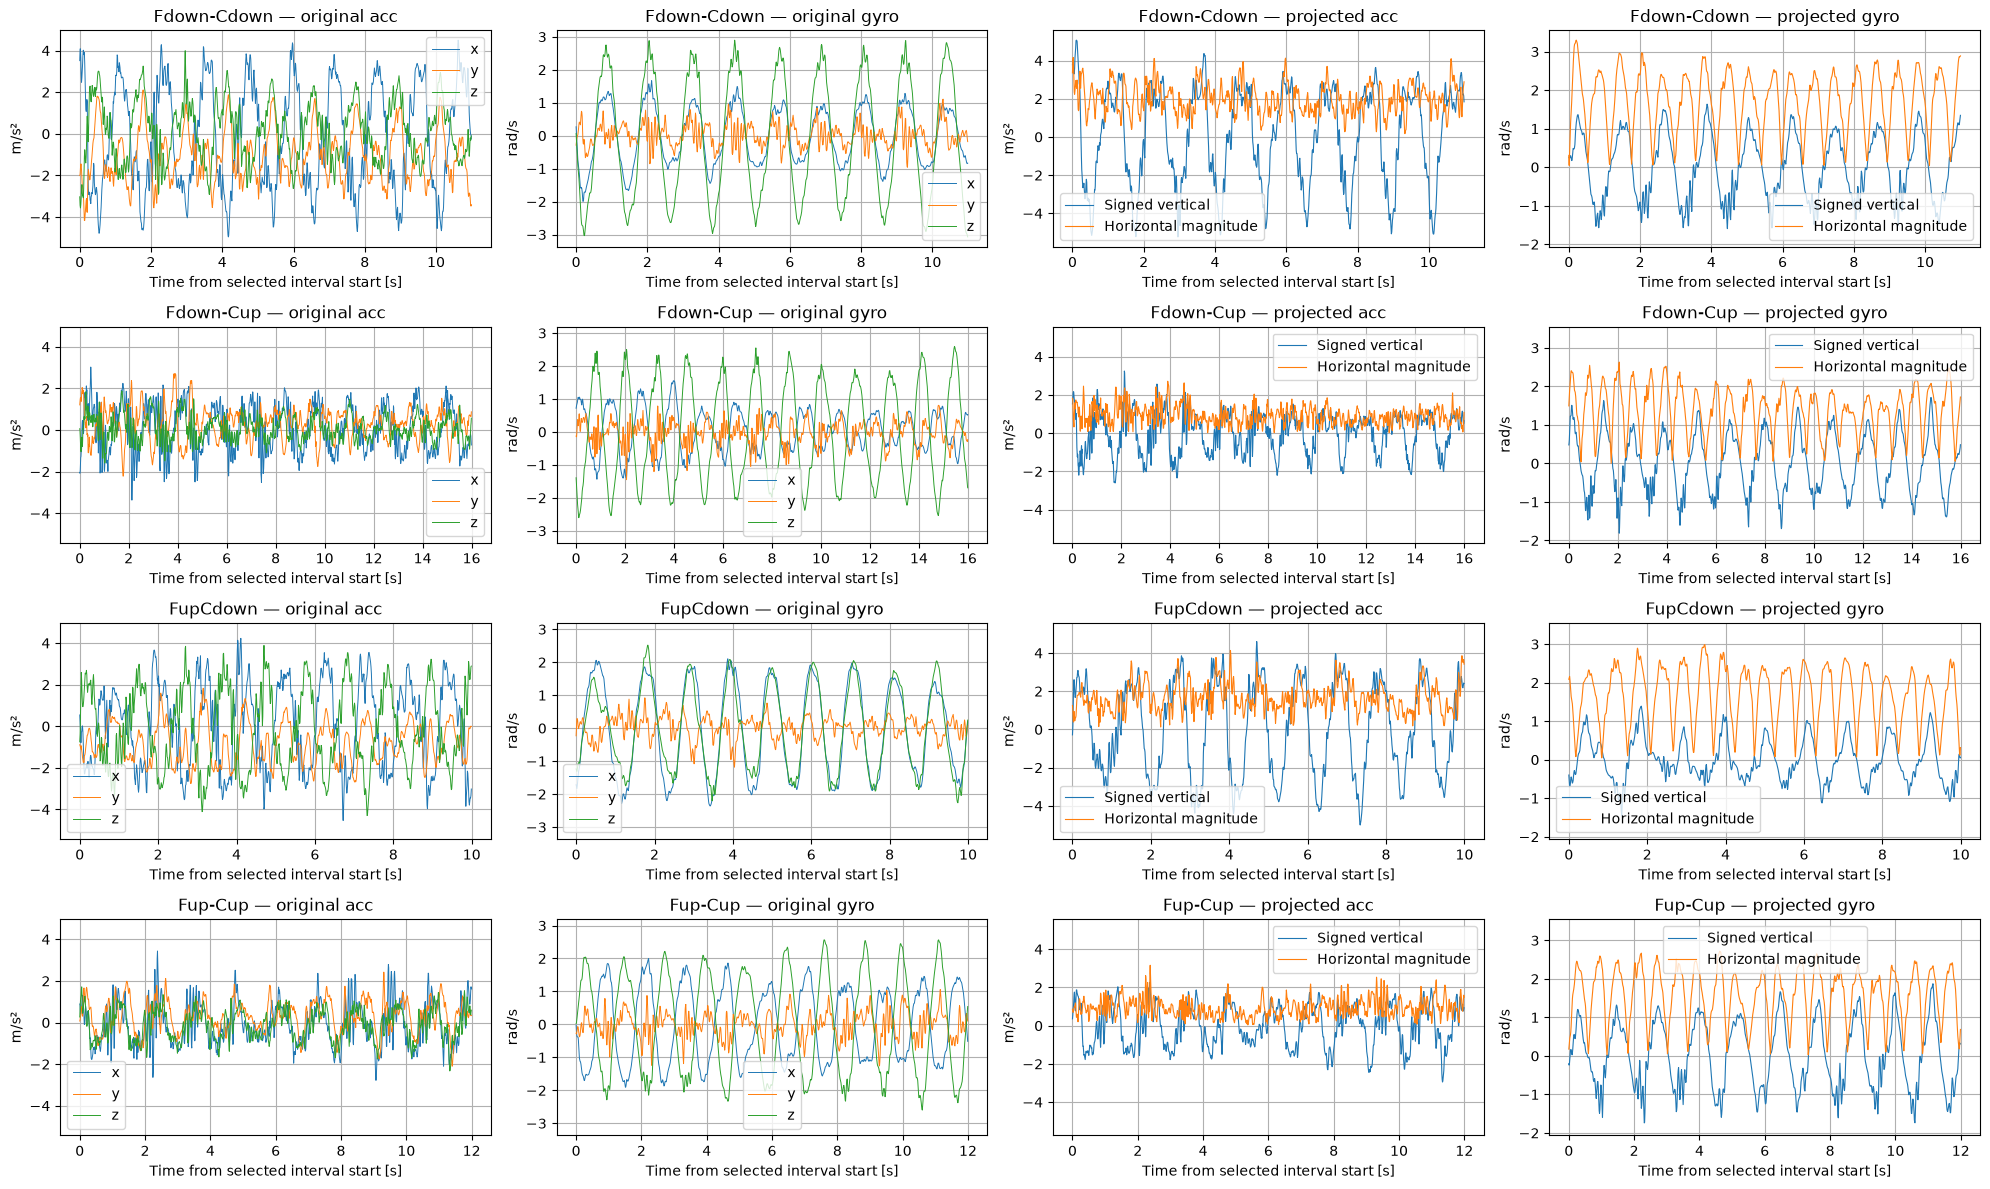

In [6]:
fig, axes = plt.subplots(len(recordings), 4, figsize=(20, 12), sharey="col", squeeze=False)
for i, name in enumerate(recordings):
    data = comparison_data[name]
    time = data.index - data.index[0]
    for j, sensor in enumerate(["acc", "gyro"]):
        columns = [sensor + "_" + axis for axis in ["x", "y", "z"]]
        axes[i, j].plot(time, data[columns], linewidth=0.7)
        axes[i, j].legend(["x", "y", "z"])
        axes[i, j].set_title(name + " — original " + sensor)
        axes[i, j + 2].plot(time, data[sensor + "_vertical"], label="Signed vertical", linewidth=0.8)
        axes[i, j + 2].plot(time, data[sensor + "_horizontal"], label="Horizontal magnitude", linewidth=0.8)
        axes[i, j + 2].set_title(name + " — projected " + sensor)
        axes[i, j + 2].legend()
        for col in [j, j + 2]:
            axes[i, col].set_ylabel("m/s²" if sensor == "acc" else "rad/s")
    for ax in axes[i]:
        ax.set_xlabel("Time from selected interval start [s]")
        ax.grid(True)
plt.tight_layout()
plt.show()


## 6. Compare the four derived signals
Overlay each derived signal across phone positions. Similar patterns support the use of this reference, but these independent movement trials cannot prove identical motion. Amplitude and phase differences can remain. In particular, compare general shapes and ranges rather than exact sample timing.


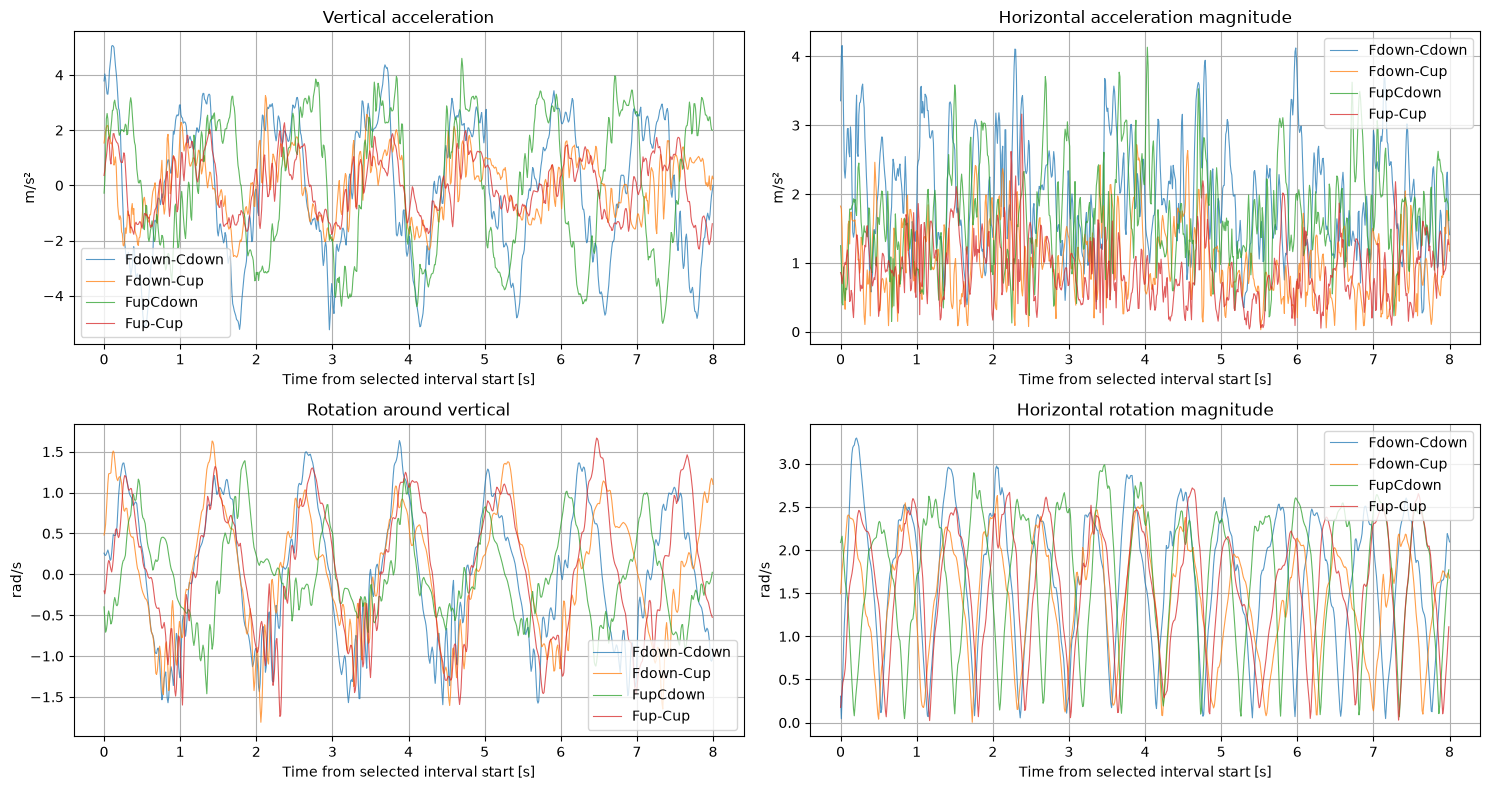

In [7]:
signals = ["acc_vertical", "acc_horizontal", "gyro_vertical", "gyro_horizontal"]
titles = ["Vertical acceleration", "Horizontal acceleration magnitude", "Rotation around vertical", "Horizontal rotation magnitude"]
units = ["m/s²", "m/s²", "rad/s", "rad/s"]
comparison_duration = 8
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for i, ax in enumerate(axes.flatten()):
    for name, data in comparison_data.items():
        time = data.index - data.index[0]
        selected = time < comparison_duration
        ax.plot(time[selected], data.loc[selected, signals[i]], label=name, alpha=0.75, linewidth=0.8)
    ax.set_title(titles[i])
    ax.set_ylabel(units[i])
    ax.set_xlabel("Time from selected interval start [s]")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


The resulting `corrected_data` keeps all original axes and the four derived signals for each recording. Assignment1 extracts window statistics and frequency features from only those four derived signals. Figures can be saved from the notebook for the report.
